In [85]:
import numpy as np

In [86]:
# 8 câu 

cau = ["Hello World!", "BKU", "US", "UIT", "Hello World! Hello World!", "FPT", "Chai nước", "Hạt gạo"]

In [87]:
# Hàm chuyển dữ liệu thành ma trận
def transform(cau):
    vocab = sorted ({w for s in cau for w in s.lower().split()})
    def to_vector(s):
        v = np.zeros(len(vocab))
        for w in s.lower().split():
            v[vocab.index(w)] += 1
        return v
    X = np.array([ to_vector(s) for s in cau]) # (so_cau , so_tu)
    print(X.shape)
    return X

Bài 1

1. Biến dữ liệu thành ma trận
    - Mỗi hàng đại diện cho mỗi câu.
    - Mỗi cột đại diện cho trong một hàng (một câu) thì có từ gì (tại vị trí hàng và cột đại diện cho câu và từ sẽ là số từ đó trong câu).

In [88]:
X = transform(cau)
X

(8, 10)


array([[0., 0., 0., 0., 1., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 2., 0., 0., 0., 0., 2.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 1., 0., 0., 0., 0.]])

2. Phép toán cơ bản

In [89]:
def average_column(X):
    my_vector = np.zeros(X.shape[1])
    total = X.shape[0]
    for row_index, row in enumerate(X):
        for column_index, column in enumerate(row):
            my_vector[column_index] += column/total
    
    return my_vector

average_column(X)



array([0.125, 0.125, 0.125, 0.125, 0.375, 0.125, 0.125, 0.125, 0.125,
       0.375])

In [90]:
def broadcasting(X):
    my_average_vector = average_column(X)
    print('Trước khi broadcasting, vector trung bình có shape: ', my_average_vector.shape)
    print('Trước khi broadcasting, ma trận X có shape: ', X.shape)

    X = X - my_average_vector
    print('Sau khi broadcasting, ma trận X có shape: ', X.shape)
    print('Ma trận X sau khi trừ trung bình: ', X)
broadcasting(X)
    

Trước khi broadcasting, vector trung bình có shape:  (10,)
Trước khi broadcasting, ma trận X có shape:  (8, 10)
Sau khi broadcasting, ma trận X có shape:  (8, 10)
Ma trận X sau khi trừ trung bình:  [[-0.125 -0.125 -0.125 -0.125  0.625 -0.125 -0.125 -0.125 -0.125  0.625]
 [ 0.875 -0.125 -0.125 -0.125 -0.375 -0.125 -0.125 -0.125 -0.125 -0.375]
 [-0.125 -0.125 -0.125 -0.125 -0.375 -0.125 -0.125 -0.125  0.875 -0.375]
 [-0.125 -0.125 -0.125 -0.125 -0.375 -0.125 -0.125  0.875 -0.125 -0.375]
 [-0.125 -0.125 -0.125 -0.125  1.625 -0.125 -0.125 -0.125 -0.125  1.625]
 [-0.125 -0.125  0.875 -0.125 -0.375 -0.125 -0.125 -0.125 -0.125 -0.375]
 [-0.125  0.875 -0.125 -0.125 -0.375 -0.125  0.875 -0.125 -0.125 -0.375]
 [-0.125 -0.125 -0.125  0.875 -0.375  0.875 -0.125 -0.125 -0.125 -0.375]]


3. Cosine similarity

In [91]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T # ma tran tuong dong

A = cosine_similarity(X)
A

array([[1., 0., 0., 0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1.]])

4. Truy vấn

In [92]:
# Hàm tìm max của một ma trận và nếu tìm được sẽ trả về index, max value
def find_max(A, already = None):
    index_max = 0
    value_max = -2
    for index, value in enumerate(A):
        if already is not None:
            if index in already:
                continue
        value = round(value,4)
        A[index] = value
        if value > value_max:
            value_max = value
            index_max = index
        already.append(index_max)
    return index_max, value_max, already


def search(query, top_k=3):
    A = cosine_similarity(query, X).tolist()[0]
    res = []
    already = []
    for i in range(top_k):
        index_max, value_max, already = find_max(A, already)
        res.append([index_max,value_max])
    return res
    

search(X[0:1])

[[0, 1.0], [4, 1.0], [2, 0.0]]

5. Nhận xét
    - Em chọn ma trận dòng đầu tiên bằng cách lấy X[0:1] 
    - Khi đối chiếu với ma trận tương đồng, ta có thể dễ dàng nhận thấy điểm similarity của dòng đầu tiên với cả ma trận X là:
    [1., 0., 0., 0., 1., 0., 0., 0.]
    -> Đáp án trả về là [0, 1.0], [4, 1.0], [2, 0.0] tuơng ứng với tại dòng 0,4 sẽ có điểm tương đồng cao nhất và không còn dòng nào tương đồng nữa.


Bài 2 — Biến đổi tuyến tính & SVD
- Nhận xét: 
    + Với array coords trả về bên dưới, ta có thể thấy các câu cùng chủ đề có nằm gần nhau, cụ thể các câu "BKU", "US", "UIT", "FPT" tạo thành các điểm gần nhau với giá trị khoảng (-5,15e-01,0); Các câu "Chai nước", "Hạt gạo" có sự tương đồng ở cột 1 là khoảng -6e-01 nhưng khác ở cột 2. Còn "Hello World!",  "Hello World! Hello World!" thì không có điểm tương đồng.
    + Ta có thể thấy rằng PC1 nắm được phần lớn thông tin để chia thành các câu cùng chủ đề, tuy nhiên chỉ dựa vào PC1 thì vẫn thiếu vì trong trường hợp "Chai nước", "Hạt gạo" thì nhờ PC2 ta mới thấy được sự khác biệt.

In [93]:
Xc = X - X.mean(axis =0)
U, S, Vt = np.linalg.svd(Xc , full_matrices=False)
coords = U[:, :2] * S[:2]

coords

array([[ 9.35901475e-01, -9.34336865e-17],
       [-5.14718587e-01, -1.01109310e-15],
       [-5.14718587e-01, -1.18894508e-15],
       [-5.14718587e-01, -7.52906048e-16],
       [ 2.32257773e+00,  1.57425240e-16],
       [-5.14718587e-01, -1.04059086e-15],
       [-5.99802429e-01,  1.00000000e+00],
       [-5.99802429e-01, -1.00000000e+00]])

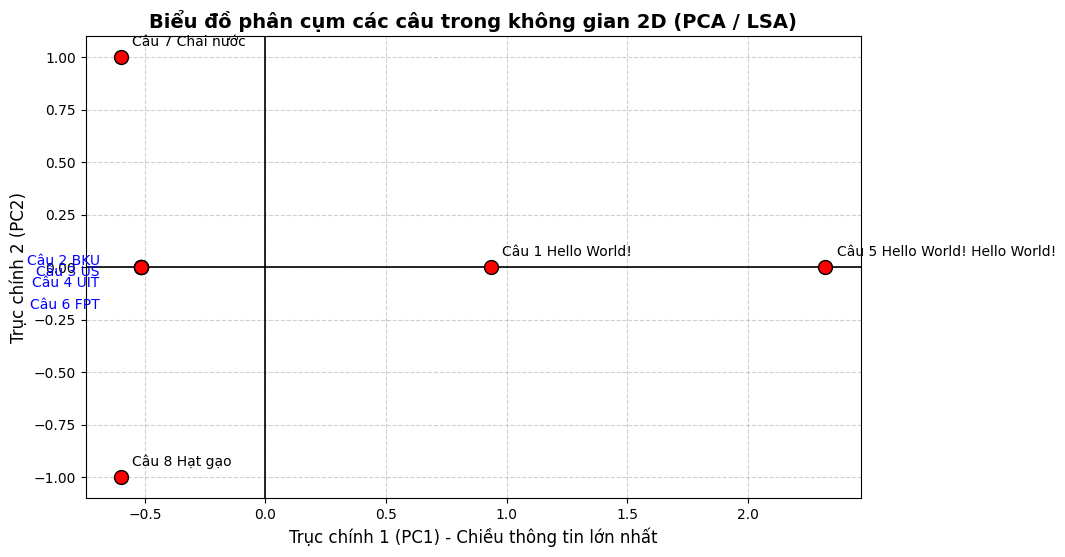

In [94]:
# Vẽ scatter các câu trên mặt phẳng 2D, gắn nhãn từng câu (Sử dụng AI)

import matplotlib.pyplot as plt

# Danh sách nhãn cho từng câu
labels = [f"Câu {i+1:} {cau[i]}" for i in range(len(coords))]

# 2. Thiết lập kích thước khung hình
plt.figure(figsize=(10, 6))

# Vẽ các điểm lên mặt phẳng (tọa độ x là cột 0, tọa độ y là cột 1)
plt.scatter(coords[:, 0], coords[:, 1], color='red', s=100, edgecolors='black', zorder=3)

# 3. Gắn nhãn cho từng điểm
for i, label in enumerate(labels):
    x, y = coords[i, 0], coords[i, 1]
    
    # Xử lý riêng cho các câu 2, 3, 4, 6 bị trùng tọa độ để chữ không bị đè lên nhau
    if i in [1, 2, 3, 5]:  # Index 1,2,3,5 tương ứng với Câu 2,3,4,6
        offset_y = 10 - (i * 8) # Dịch chuyển nhãn lên/xuống một chút
        plt.annotate(label, (x, y), textcoords="offset points", xytext=(-30, offset_y), ha='right', color='blue')
    else:
        # Gắn nhãn bình thường cho các câu khác
        plt.annotate(label, (x, y), textcoords="offset points", xytext=(8, 8), ha='left')

# 4. Trang trí biểu đồ cho dễ nhìn
plt.axhline(0, color='black', linewidth=1.2, linestyle='-') # Vẽ trục tung (PC1)
plt.axvline(0, color='black', linewidth=1.2, linestyle='-') # Vẽ trục hoành (PC2)
plt.grid(True, linestyle='--', alpha=0.6, zorder=0)

plt.title("Biểu đồ phân cụm các câu trong không gian 2D (PCA / LSA)", fontsize=14, fontweight='bold')
plt.xlabel("Trục chính 1 (PC1) - Chiều thông tin lớn nhất", fontsize=12)
plt.ylabel("Trục chính 2 (PC2)", fontsize=12)

# Hiển thị biểu đồ
plt.show()